In [1]:
from torch import nn as nn
import torch
import torch.autograd as ag
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from numpy import exp


# def differential_equation(TD: torch.Tensor):
#     return -(delta_D * TD)

#initial
TI0 = 31.5
TD0_value = 16.2
TNI0 = 1.26
L0 = 2.71E9
scale = 1e11
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TD0 = torch.tensor([TD0_value], dtype=torch.float32, device=device)
#TD0 = TD0 /scale
TI0 = (torch.tensor([TI0], dtype=torch.float32, device=device))
TNI0 = (torch.tensor([TNI0], dtype=torch.float32, device=device))
L0 = (torch.tensor([L0], dtype=torch.float32, device=device))
#TI0 = TI0/scale
# def solution(x):
#     return TD0 * exp(-delta_D * x)

#Parameters
K = 1000
mu = 0.1
p1 = 1
p2 = 20
KL = 2E10
s = 1.5E8
delta_D = 0.2
delta_L = 0.033
D = 240
lamda = 0.1
kappa = 0.01
omega = 0.007
gamma = 0.03
r = 5
cCTLA4 = 2
PD1 = 2
cL = 1E8
L = 1E8

scale = 1e11

In [3]:
#Building Neural Network Model
#base class for all neural network modules
class PINNModel(nn.Module):
    #constructor that takes in the parameters for the model
    def __init__(self, input_size: int = 1, output_size: int = 4, hidden_layers: int = 5, hidden_nodes: int = 64):
        super().__init__()
        #connecting the layers using nn.Linear(input,output)
        self.inputs = nn.Linear(input_size, hidden_nodes)
        self.model = nn.ModuleList([nn.Linear(hidden_nodes, hidden_nodes) for _ in range(hidden_layers)]) #creates list of these layers to iterate through
        self.outputs = nn.Linear(hidden_nodes, output_size)

        self.activation = nn.Tanh() # makes it nonlinear

    #applies activation to all layers in the model
    def _apply_model(self,x: torch.Tensor):
        for layer in self.model:
            x = self.activation(layer(x))
        return x

    #This is the prediction function
    def forward(self, t: torch.Tensor):
        t = t / 100.0
        t = self.activation(self.inputs(t))
        t = self._apply_model(t)
        t = self.outputs(t)
        return t


In [ ]:
#Preparing Points for Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.linspace(0, 100, 1000).reshape(-1, 1) #many data points
#y = solution(x).reshape(-1, 1) #analytical solution for the differential equation
torch.exp(-delta_D*x)
#y = (TD0 * exp(-delta_D * x.numpy())).reshape(-1, 1)

#take only certain points for training
# x_data = x[0:200:10]
# y_data = y[0:200:10]

#move tensors to the selected device
# x_data_t = x_data.detach().clone().to(device=device, dtype=torch.float32).reshape(-1, 1)
# y_data_t = y_data.detach().clone().to(device=device, dtype=torch.float32).reshape(-1, 1)

#creating points for physics loss
x_physics = torch.linspace(0, 100, 1000, requires_grad=True, device=device, dtype=torch.float32).reshape(-1, 1)
#norm  = 200.0 

In [ ]:
#Training Loop
#Goals: Match the data points and satisfy the differential equation
Epochs = 20000
Length = 1e-3

model = PINNModel().to(device) #create neural network
optimize = torch.optim.Adam(model.parameters(), lr=1e-3) #optimizer for the model parameters


#data_loss = nn.MSELoss()

#for loop that trains the model
for epoch in range(Epochs):
    optimize.zero_grad() #reset the gradient to 0 at the start of each loop
    
    #data loss
    # y_pred = model(x_data_t) #generates prediction
    # TD_pred = y_pred[:, 0:1] #extracts the first column of the prediction
    # TI_pred = y_pred[:, 1:2] #extracts the second column of the prediction
    #loss_data = data_loss(TD_pred, y_data_t[:, 0:1]) + data_loss(TI_pred, y_data_t[:, 1:2]) #compares prediction to the data points and calculates the loss

    prediction = model(x_physics) #generates prediction for physics points
    TD_hat = (prediction[:, 0:1])
    TI_hat = (prediction[:, 1:2])
    TNI_hat = (prediction[:, 2:3])
    L_hat = (prediction[:, 3:4])

    TD_physics  = TD_hat  #* norm
    TI_physics  = TI_hat  #* norm
    TNI_physics = TNI_hat #* norm
    L_physics = L_hat * L_norm
    #L_physics = prediction[:, 3:4] #if prediction.shape[1] > 3 else torch.zeros_like(TI_physics)
    T = TI_physics + TD_physics + TNI_physics
    T_safe = torch.clamp(T, min=1e-8)
    Zp = (omega * (L_physics / cL)) / (1 + ((kappa * (T_safe ** (2/3)) * (L_physics / cL)) / (1 + PD1)))
    Zs = (gamma * ((1 + cCTLA4)/(r + cCTLA4)))#create another differential equation and solve it for the integration

    #TD loss
    #prediction = model(x_physics) #generates prediction for physics points
    #TD_physics = prediction[:, 0:1]
    dTD = ag.grad(TD_physics, x_physics, grad_outputs=torch.ones_like(TD_physics), create_graph=True)[0]  # calculates derivative
    Residual_TD = dTD + delta_D * TD_physics #calculates physics loss
    #loss_TD = torch.mean(Residual_TD**2) #calculates mean squared error for physics loss

    #TI Loss
    #TI_physics = prediction[:, 1:2] #generates prediction for physics points
    dTI = ag.grad(TI_physics, x_physics, grad_outputs=torch.ones_like(TI_physics), create_graph=True)[0]  # calculates derivative
    Residual_TI = dTI - (mu * TI_physics * (1 - ((TI_physics + TD_physics)/K)) - (Zp * TI_physics) - (Zs * TI_physics)) #calculates physics loss
    #loss_TI = torch.mean(Residual_TI**2) #calculates mean squared error for physics loss

    # #TNI Loss
    #TNI_physics = prediction[:, 2:3]
    dTNI = ag.grad(TNI_physics, x_physics, grad_outputs=torch.ones_like(TNI_physics), create_graph=True)[0]
    Residual_TNI = dTNI - (mu * TNI_physics) * (1 - (TNI_physics/K)) - (Zp * TNI_physics) - (Zs * TNI_physics)
    #loss_TNI = torch.mean(Residual_TNI**2) #calculates mean squared error for physics loss


    #L Loss
    L_physics = prediction[:, 3:4]
    dL = ag.grad(L_physics, x_physics, torch.ones_like(L_physics),create_graph=True)[0]
    Residual_L = dL - (lamda * ((p1 * (TI_physics + TNI_physics))/(K + TI_physics + TNI_physics) + ((p2 * dTD)/(K + dTD))) * (L_physics) * (1 - (L_physics/KL)) + s - (delta_L) * (L_physics))
    #loss_L = torch.mean(Residual_L**2) #calculates mean squared error for physics loss


    # #nPL Loss
    # nPL_physics = prediction[:, 4:5]
    # dnPL = ag.grad(nPL_physics, x_physics, torch.ones_like(L_physics),create_graph=True)[0]
    # Residual_nPL = dnPL - ((nPL_physics) * (D) - (ePL) * (nPL_physics) - (e2PL) * (nPL_physics)**2)
    # loss_nPL = torch.mean(Residual_nPL**2) #calculates mean squared error for physics loss


    # #nL Loss
    # nL_physics = prediction[:, 5:6]
    # dnL = ag.grad(nL_physics, x_physics, torch.ones_like(L_physics),create_graph=True)[0]
    # Residual_nL = dnL - (((nL_physics) * (D) + (e2PL * (nPL_physics)**2)))
    # loss_nL = torch.mean(Residual_nL**2) #calculates mean squared error for physics loss

    loss_TD  = torch.mean((Residual_TD)**2)
    loss_TI  = torch.mean((Residual_TI)**2)
    loss_TNI = torch.mean((Residual_TNI)**2)
    loss_L  = torch.mean((Residual_L)**2)
    #adding initial loss
    initial = model(torch.tensor([[0.0]], device=device, dtype=torch.float32)) #prediction at initial condition
    TI0_pred = initial[:, 1:2] #* norm
    TD0_pred = initial[:, 0:1] #* norm
    TNI0_pred = initial[:, 2:3] #* norm
    TL0_pred = initial[:, 3:4] #* norm
    
    initial_loss = (
    ((TD0_pred  - TD0))**2 +
    ((TI0_pred  - TI0))**2 +
    ((TNI0_pred - TNI0))**2 +
    ((TL0_pred - L0))**2
    ).mean()
    # print(torch.isnan(prediction).any())
    # print(torch.isnan(T).any())
    # print(torch.isnan(Zp).any())
    # print(torch.isnan(Residual_TD).any())
    # print(torch.isnan(Residual_TI).any())


    loss_physics = loss_TD + loss_TI + loss_TNI + loss_L #+ loss_nPL + loss_nL
    total_loss = loss_TD + (5 * loss_TI) + (5 * loss_TNI) + (5 * loss_L) + (100 * initial_loss)

    total_loss = total_loss.mean()  # ensure scalar loss before backprop
    total_loss.backward()  # figures out what weights caused the error
    optimize.step() #fixes the model slightly to minimize error
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Total Loss: {total_loss.item()}, Physics Loss: {loss_physics.item()}, Initial Loss: {initial_loss.item()}")

Epoch: 0, Total Loss: 7.345226032628273e+20, Physics Loss: 2.250000007639859e+16, Initial Loss: 7.344100506555384e+18
Epoch: 1000, Total Loss: 7.345226032628273e+20, Physics Loss: 2.250000007639859e+16, Initial Loss: 7.344100506555384e+18
Epoch: 2000, Total Loss: 7.34522462525339e+20, Physics Loss: 2.250000007639859e+16, Initial Loss: 7.344099407043756e+18
Epoch: 3000, Total Loss: 7.34522462525339e+20, Physics Loss: 2.249998933898035e+16, Initial Loss: 7.344099407043756e+18
Epoch: 4000, Total Loss: 7.34522462525339e+20, Physics Loss: 2.2501477545148416e+16, Initial Loss: 7.344099407043756e+18
Epoch: 5000, Total Loss: 7.34522462525339e+20, Physics Loss: 2.25012262895616e+16, Initial Loss: 7.344099407043756e+18
Epoch: 6000, Total Loss: 7.345223217878506e+20, Physics Loss: 2.250109529305907e+16, Initial Loss: 7.344097757776314e+18
Epoch: 7000, Total Loss: 7.345223217878506e+20, Physics Loss: 2.2500994361327616e+16, Initial Loss: 7.344097757776314e+18
Epoch: 8000, Total Loss: 7.34522321787

TD residual mean: 10.387079238891602
TI residual mean: 708.4295654296875


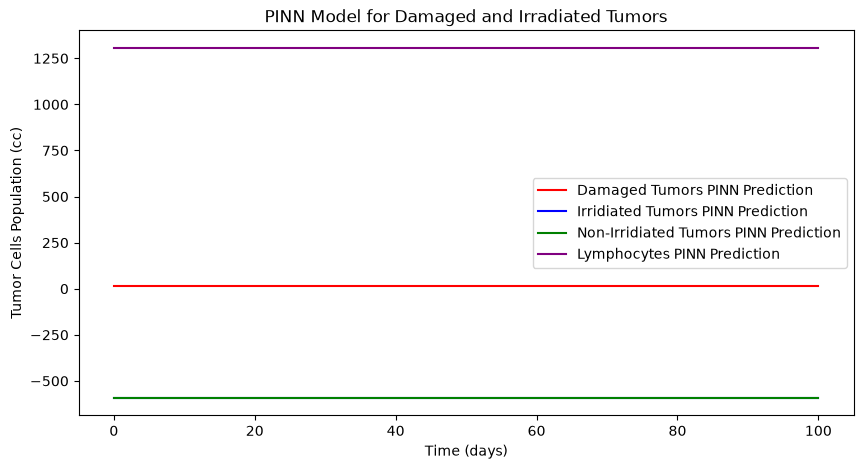

In [6]:
#Testing the Model
model.eval()
x_test = x.detach().clone().to(device=device, dtype=torch.float32)
y_pred = model(x_test).detach().cpu().numpy()#get Pinn Solution curve
TD_pred = y_pred[:, 0] #* norm  # Extract the first column for TD predictions
TI_pred = y_pred[:, 1] #* norm # Extract the second column for TI predictions
TNI_pred = y_pred[:, 2] #* norm # Extract the third column for TNI predictions
L_pred = y_pred[:, 3] #* norm # Extract the fourth column for L predictions
#Plotting the Neural Network Model vs Analytical Solution
plt.figure(figsize=(10, 5))
plt.title("PINN Model for Damaged and Irradiated Tumors")
#plt.plot(x, y, label="Analytical Solution", color="pink", linewidth=7)
plt.xlabel("Time (days)")
plt.ylabel("Tumor Cells Population (cc)")

#plotting the analytical solution
# y_pred is currently flattened from (100, 6) -> (600, 1), so recover (100, 6) first
# plt.plot(x.cpu().numpy(), TD_pred, label="Damaged Tumors PINN Prediction", color="red")
# plt.plot(x.cpu().numpy(), TI_pred, label="Irridiated Tumors PINN Prediction", color="blue")

print("TD residual mean:", loss_TD.item())
print("TI residual mean:", loss_TI.item())

t = x.cpu().numpy()

true_TD = TD0_value *np.exp(-delta_D * t)   # if TD0 was normalized to 1
#plt.plot(t, true_TD, label="TD analytical (pure decay)", color="pink", linewidth=7)

plt.plot(x.cpu().numpy(), TD_pred, label="Damaged Tumors PINN Prediction", color="red")
plt.plot(x.cpu().numpy(), TI_pred, label="Irridiated Tumors PINN Prediction", color="blue")
plt.plot(x.cpu().numpy(), TNI_pred, label="Non-Irridiated Tumors PINN Prediction", color="green")
plt.plot(x.cpu().numpy(), L_pred, label="Lymphocytes PINN Prediction", color="purple")
# plt.plot(t, true_TD, label="Exact")
#plt.plot(t, TD_pred, '--', label="PINN")
#plt.plot(t, true_TD, label="TD analytical (pure decay)", color="pink", linewidth=7)
#plt.plot

true_TD = TD0_value *np.exp(-delta_D * t)   # if TD0 was normalized to 1
true_TI = mu * TI0 * (1 - ((TI0 + TD0_value)/K)) - (Zp * TI0) - (Zs * TI0)
plt.legend()

#plotting the training data points
#plt.plot(x_data, y_data, label="Data Points", color="blue", linestyle="None", marker="o")
plt.legend()
plt.show()